### Assignment-1

In [1]:
!pip install pandas
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('C:/Users/SRIVIDYA GAJJALA/Datasets/preprocessed_earthquake_data.csv')
df.sample(100)

,latitude,longitude,depth,mag,magType,rms,type,status,Year,Month,Day,Hour,Minute,Second,DayOfWeek
50922,39.5530,40.1900,-0.476886,-0.294785,mb,1.107324,earthquake,reviewed,1995,12,5,18,52,37,1
97528,-7.9833,-74.3147,0.797542,-0.712422,mww,-1.626835,earthquake,reviewed,2023,7,19,10,12,29,2
20924,3.6730,125.6940,0.266443,-0.294785,mb,-0.026749,earthquake,reviewed,1976,10,30,15,53,57,5
51669,-22.4350,-179.7460,4.828622,-0.921240,mb,-0.323340,earthquake,reviewed,1996,8,27,6,34,42,1
58097,51.7860,-175.3050,-0.263179,0.331670,mwc,0.153548,earthquake,reviewed,2001,9,21,23,56,39,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108747,19.6495,121.5052,-0.143754,0.122851,mww,-0.514096,earthquake,reviewed,2025,7,20,5,45,33,6
16567,-6.1630,151.7940,-0.402553,-0.085967,mb,0.000357,earthquake,reviewed,1973,11,8,21,7,50,3
103012,11.5390,-86.8399,-0.179536,-0.712422,mww,0.598644,earthquake,reviewed,2024,8,7,12,38,22,2
61407,35.0360,-4.0220,-0.569802,-0.712422,mwc,-0.044029,earthquake,reviewed,2004,3,7,6,37,52,6


In [4]:
!pip install matplotlib
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

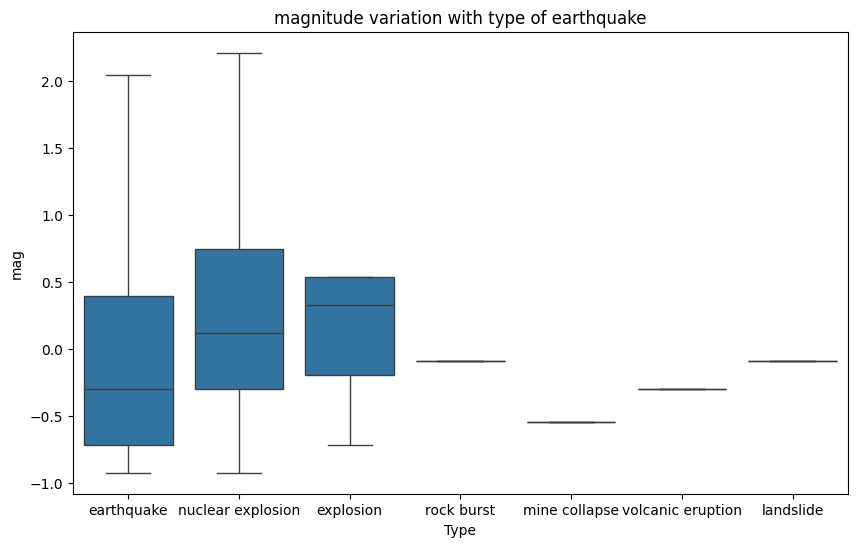

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

# Boxplot for mag by type of earthquake
sns.boxplot(x='type', y='mag', data=df, showfliers=False)  # Hides outliers to see points clearly


plt.title('magnitude variation with type of earthquake')
plt.xlabel('Type')
plt.ylabel('mag')
plt.show()

Observation:

*for explosion the mean magnitude is high around 0.4 compared to others

*for nuclear explosion the mean magnitude is around 0.2 and for eathquake it is about -0.4 and for rest of the types they didnt occur mostly.

*if we look at explosion above mean it is tigtly packed indicating most of the magnitudes are above mean i.e high.

*for nuclear explosion and earthquake above mean it is spreaded hence the chances of high magnitude is less.

Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

          depth       mag
depth  1.000000 -0.009989
mag   -0.009989  1.000000


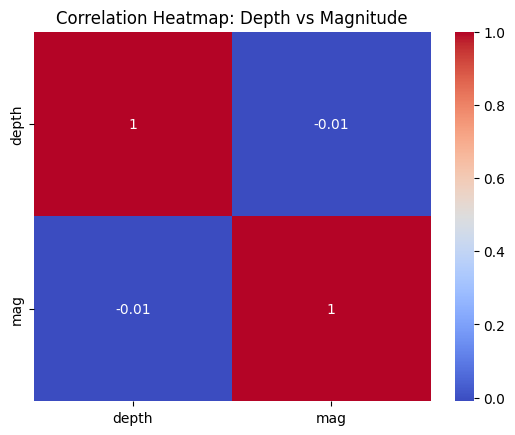

In [7]:
corr = df[['depth', 'mag']].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Depth vs Magnitude')
plt.show()

Observation:

There is no relationship between magnitude and depth.

Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

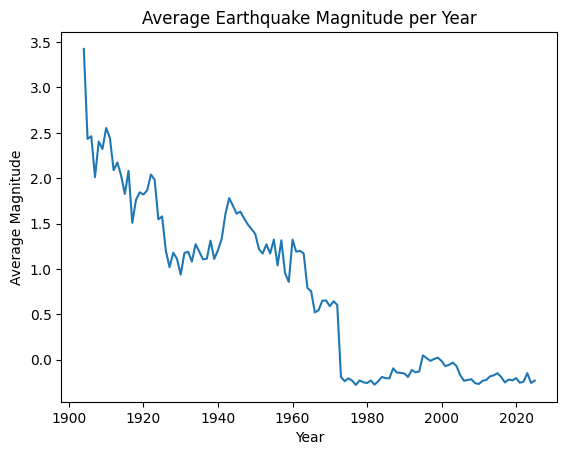

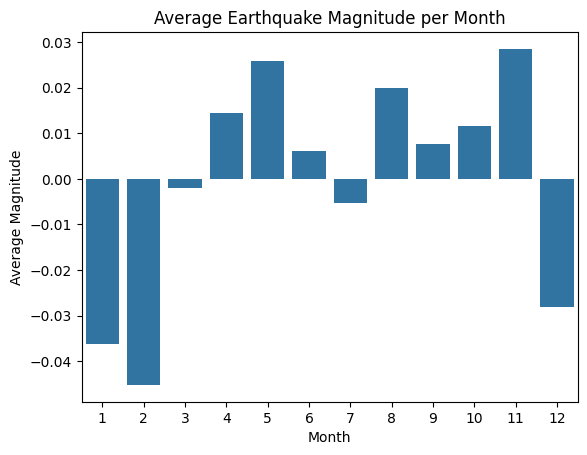

In [11]:
yearly_avg = df.groupby('Year')['mag'].mean().reset_index()
monthly_avg = df.groupby('Month')['mag'].mean().reset_index()
sns.lineplot(x='Year', y='mag', data=yearly_avg)
plt.title('Average Earthquake Magnitude per Year')
plt.xlabel('Year')
plt.ylabel('Average Magnitude')
plt.show()
sns.barplot(x='Month', y='mag', data=monthly_avg)
plt.title('Average Earthquake Magnitude per Month')
plt.xlabel('Month')
plt.ylabel('Average Magnitude')
plt.show()


Observarion:

I used lineplot for year as years increase and line plot will help in seeing how it is varied with increasing years.
over years the magnitude per year decreased.

as months are categorical I used barplot for the discrete values.in mid-months the average magnitude of earthquakes were high and in the early and last month the earthquakes magnitude is less.

Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

<Axes: xlabel='latitude', ylabel='longitude'>

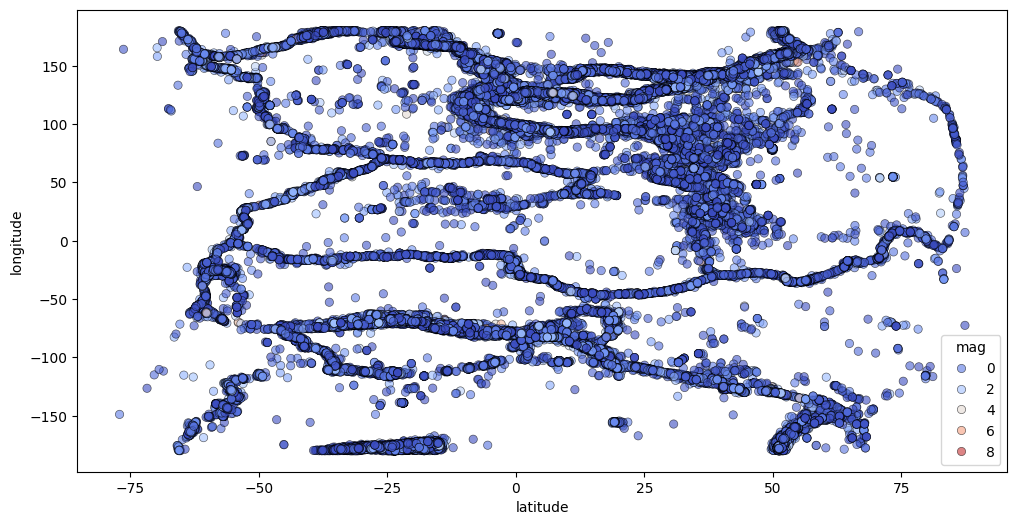

In [13]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='latitude',y='longitude',data=df,hue='mag',palette='coolwarm',        
    alpha=0.6,             
    edgecolor='k'          
)

The Pacific Ring of Fire shows particularly high activity, with a dense cluster of events around the coasts of South America, Japan, and Indonesia.